In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **ANALYSING ECOMMERCE SALES DROP**

We are seeing a drop in revenue, find the reason and suggest actions

In [ ]:
# loading the customer data

customers = pd.read_csv('customers.csv')
customers.head()

,customer_id,customer_name,signup_date
0,101,Ravi,2023-11-10
1,102,Sneha,2023-12-01
2,103,Amit,2023-12-15
3,104,Pooja,2024-01-05
4,105,Kiran,2024-01-20


In [ ]:
# loading the order data

orders = pd.read_csv('orders.csv')
orders.head()

,order_id,customer_id,product_id,order_date,city,quantity
0,1,101,201,2024-01-05,Hyderabad,1
1,2,102,202,2024-01-06,Bangalore,2
2,3,103,203,2024-01-10,Chennai,1
3,4,101,202,2024-02-12,Hyderabad,1
4,5,104,204,2024-02-18,Bangalore,3


In [ ]:
# loading the product data

products = pd.read_csv('products.csv')
products.head()

,product_id,product_name,category,price
0,201,Laptop,Electronics,70000
1,202,Mobile,Electronics,20000
2,203,Tablet,Electronics,15000
3,204,Shoes,Fashion,3000
4,205,Watch,Fashion,5000


## **EDA(Exploratory Data Analysys)**

In [ ]:
customers

,customer_id,customer_name,signup_date
0,101,Ravi,2023-11-10
1,102,Sneha,2023-12-01
2,103,Amit,2023-12-15
3,104,Pooja,2024-01-05
4,105,Kiran,2024-01-20
5,106,Arjun,2024-02-02
6,107,Divya,2024-02-15
7,108,Rahul,2024-03-01
8,109,Meena,2024-03-10
9,110,Vikram,2024-04-01


In [ ]:
orders

,order_id,customer_id,product_id,order_date,city,quantity
0,1,101,201,2024-01-05,Hyderabad,1
1,2,102,202,2024-01-06,Bangalore,2
2,3,103,203,2024-01-10,Chennai,1
3,4,101,202,2024-02-12,Hyderabad,1
4,5,104,204,2024-02-18,Bangalore,3
5,6,105,201,2024-03-05,Chennai,1
6,7,102,203,2024-03-15,Bangalore,1
7,8,106,205,2024-04-02,Hyderabad,2
8,9,107,202,2024-04-10,Chennai,1
9,10,108,204,2024-04-18,Bangalore,2


In [ ]:
df = pd.merge(customers, orders, on = "customer_id")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1


In [ ]:
products

,product_id,product_name,category,price
0,201,Laptop,Electronics,70000
1,202,Mobile,Electronics,20000
2,203,Tablet,Electronics,15000
3,204,Shoes,Fashion,3000
4,205,Watch,Fashion,5000


In [ ]:
# merging the datasets

df = pd.merge(df, products, on = "product_id")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
# converting the object datatype of signup date into datetime format

df['signup_date'] = pd.to_datetime(df['signup_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
# converting the object datatype of order date into datetime format

df['order_date'] = pd.to_datetime(df['order_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
# creating revenue column
# revenue = price * quanity

df["revenue"] = df["price"] * df["quantity"]
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


In [ ]:
# Revenue trend based on order date

revenue = df.groupby("order_date")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
revenue

,order_date,revenue
0,2024-01-05,70000
1,2024-01-06,40000
2,2024-01-10,15000
3,2024-02-12,20000
4,2024-02-18,9000
5,2024-03-05,70000
6,2024-03-15,15000
7,2024-04-02,10000
8,2024-04-10,20000
9,2024-04-18,6000


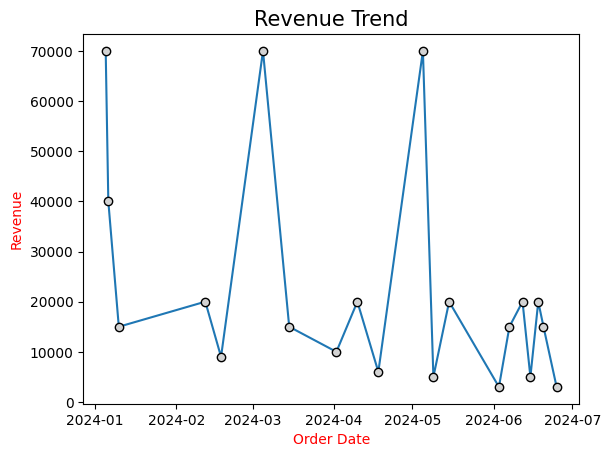

In [ ]:
# visualizing the revenue trend based on order date

plt.plot(revenue["order_date"], revenue["revenue"], marker = "o", mfc = "lightgrey", mec = "black")
plt.xlabel("Order Date", color = "red")
plt.ylabel("Revenue", color = "red")
plt.title("Revenue Trend", fontsize = 15)
plt.show()

The revenue is dropping in the last two months of june and july

In [ ]:
# Revenue trend based on City

revenue = df.groupby("city")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
revenue

,city,revenue
0,Bangalore,136000
1,Chennai,140000
2,Hyderabad,175000


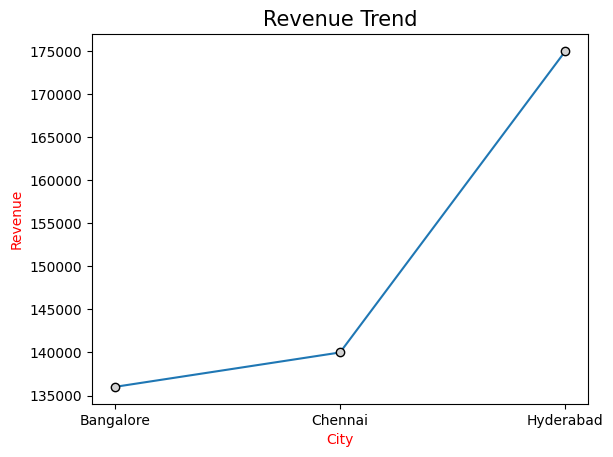

In [ ]:
# visualizing the revenue trend based on city

plt.plot(revenue["city"], revenue["revenue"], marker = "o", mfc = "lightgrey", mec = "black")
plt.xlabel("City", color = "red")
plt.ylabel("Revenue", color = "red")
plt.title("Revenue Trend", fontsize = 15)
plt.show()

In [ ]:
# Revenue trend based on Category

revenue = df.groupby("category")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
revenue

,category,revenue
0,Electronics,410000
1,Fashion,41000


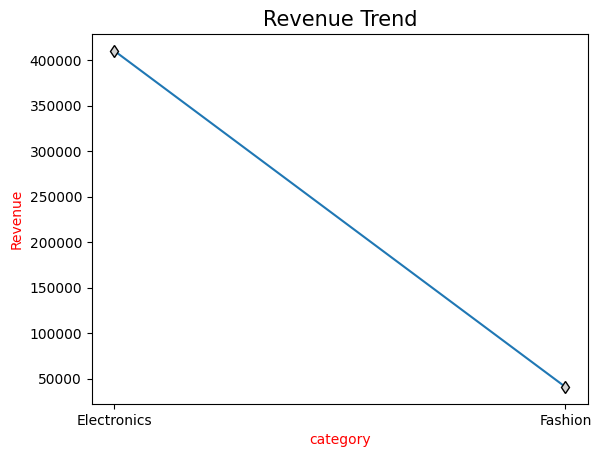

In [ ]:
# visualizing the revenue trend category

plt.plot(revenue["category"], revenue["revenue"], marker = "d", mfc = "lightgrey", mec = "black")
plt.xlabel("category", color = "red")
plt.ylabel("Revenue", color = "red")
plt.title("Revenue Trend", fontsize = 15)
plt.show()

In [ ]:
# Revenue trend based on Product

revenue = df.groupby("product_name")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
revenue

,product_name,revenue
0,Laptop,210000
1,Mobile,140000
2,Shoes,21000
3,Tablet,60000
4,Watch,20000


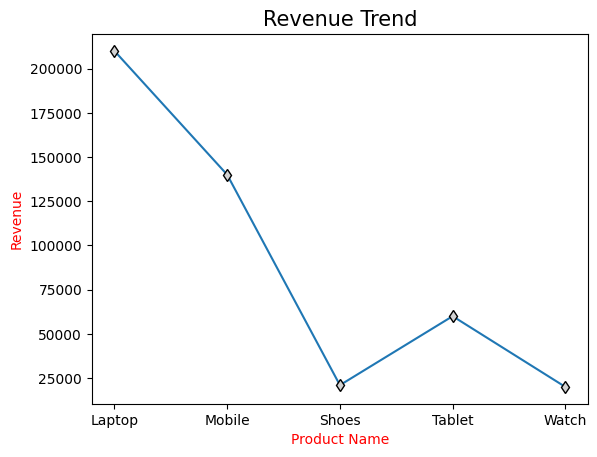

In [ ]:
# visualizing the revenue trend based on Products

plt.plot(revenue["product_name"], revenue["revenue"], marker = "d", mfc = "lightgrey", mec = "black")
plt.xlabel("Product Name", color = "red")
plt.ylabel("Revenue", color = "red")
plt.title("Revenue Trend", fontsize = 15)
plt.show()

In [ ]:
# Revenue trend based on Product

revenue = df.groupby("product_name")["quantity"].sum()
revenue = pd.DataFrame(revenue).reset_index()
revenue

,product_name,quantity
0,Laptop,3
1,Mobile,7
2,Shoes,7
3,Tablet,4
4,Watch,4


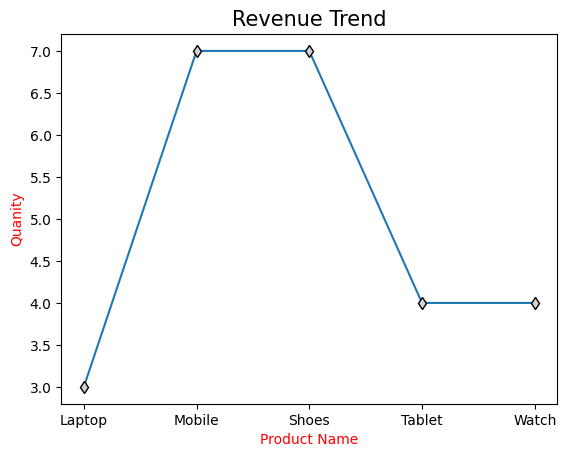

In [ ]:
# visualizing the revenue trend based on Products

plt.plot(revenue["product_name"], revenue["quantity"], marker = "d", mfc = "lightgrey", mec = "black")
plt.xlabel("Product Name", color = "red")
plt.ylabel("Quanity", color = "red")
plt.title("Revenue Trend", fontsize = 15)
plt.show()

# **Insights:**
* Revenue got dropped in the last two months(jun,jul)
* Banglore contributed more in revenue drop
* Fashion category recorded less revenue
* Repeated customers ordered less
* Shoe and watch sales declined significantly


# **Recommendations:**
* Marketing should be done in banglore
* Provide discounts on laptop, tablets.
* coupens,discounts,loyalty programs for repeated customers